# **Employee Attrition Analysis & Prediction**
First of all, we load necessary python libraries, and of course load and inspect the dataset

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

print(os.listdir())
warnings.filterwarnings('ignore')
attr = pd.read_csv("Employee Data.csv")

['.git', '.gitignore', '.ipynb_checkpoints', 'Employee Data Analysis.ipynb', 'Employee Data.csv', 'README.md']


In [16]:
attr

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,Female,High,Rare,Sales,Engineering,Medium,Near,Yes
1,Male,Low,Frequent,Sales,Engineering,Low,Near,Yes
2,Male,Medium,Rare,R&D,Other,Medium,Far,No
3,Female,Low,Frequent,R&D,Engineering,Medium,Far,Yes
4,Male,Medium,Rare,R&D,Medical,Medium,Far,No
...,...,...,...,...,...,...,...,...
95,Female,High,Rare,R&D,Technical Degree,Medium,Near,No
96,Female,High,Rare,Sales,Other,Low,Near,Yes
97,Male,High,No,Sales,Medical,Medium,Near,No
98,Male,Medium,Rare,Sales,Medical,High,Near,No


In [17]:
attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           100 non-null    object
 1   Satisfaction     100 non-null    object
 2   Business Travel  100 non-null    object
 3   Department       100 non-null    object
 4   EducationField   100 non-null    object
 5   Salary           100 non-null    object
 6   Home-Office      100 non-null    object
 7   Attrition        100 non-null    object
dtypes: object(8)
memory usage: 6.4+ KB


Dataset contains 100 observations. No missing values and all object data types that will need to be encoded

In [18]:
attr.duplicated().sum()

np.int64(9)

In [19]:
attr = attr.drop_duplicates()
attr.duplicated().sum()

np.int64(0)

Dataset now has no redundant data items

# Step 2
Next order of business is to carry out Exploratory Data Analysis by visualisation. To do this, we will need to carry out the required preprocessing for EDA.

In [20]:
# nested mappings for multiple columns
encodings = {
    'Satisfaction': {
        'Low': 0,
        'Medium': 1,
        'High': 2
    },
    'Salary': {
        'Low': 0,
        'Medium': 1,
        'High': 2
    }
}
attr = attr.replace(encodings)

In [21]:
attr.head(6)

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,Female,2,Rare,Sales,Engineering,1,Near,Yes
1,Male,0,Frequent,Sales,Engineering,0,Near,Yes
2,Male,1,Rare,R&D,Other,1,Far,No
3,Female,0,Frequent,R&D,Engineering,1,Far,Yes
4,Male,1,Rare,R&D,Medical,1,Far,No
5,Male,2,Frequent,R&D,Engineering,0,Far,No


Now satisfaction & salary, presumably the two most influential features on attrition, can both be quantified

<function matplotlib.pyplot.show(close=None, block=None)>

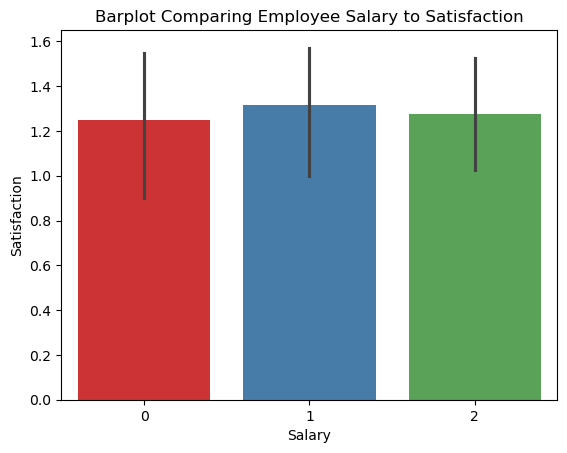

In [22]:
sns.barplot(x='Salary', y='Satisfaction', data=attr, palette='Set1') # the palette attribute chooses a colour set for the plot
plt.title("Barplot Comparing Employee Salary to Satisfaction")
plt.show

We can infer from the slim height differences on this bar chart that suprisingly, employee salary and satifaction did not have any strong correlation. Those with medium range salaries reported the greates overall satisfaction, averaging slightly short of the mid point between high & medium. The lowest average satisfaction was found among members of the low salary range, although difference was narrow.

Text(0.5, 1.0, 'Stacked countplot showing attrition proportion among each satisfaction level')

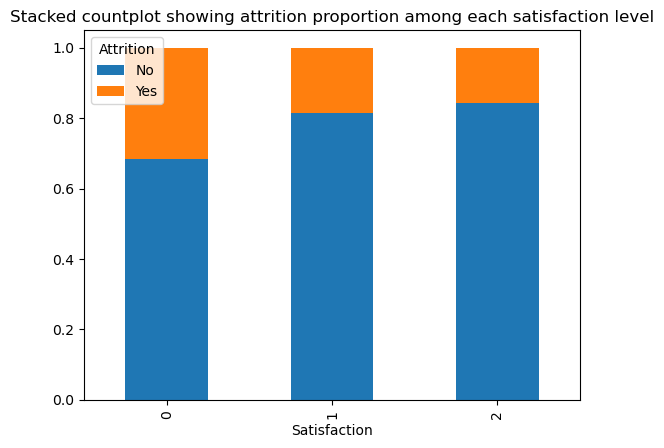

In [23]:
# normalised to display as proportions rather than counts
pd.crosstab(attr['Satisfaction'], attr['Attrition'], normalize='index').plot(kind='bar', stacked=True) 
plt.title("Stacked countplot showing attrition proportion among each satisfaction level")

As one may have guessed, satisfaction shows visible correlation to attrition. The proportion of employees who left the company is noticably less in higher satisfaction levels.

<function matplotlib.pyplot.show(close=None, block=None)>

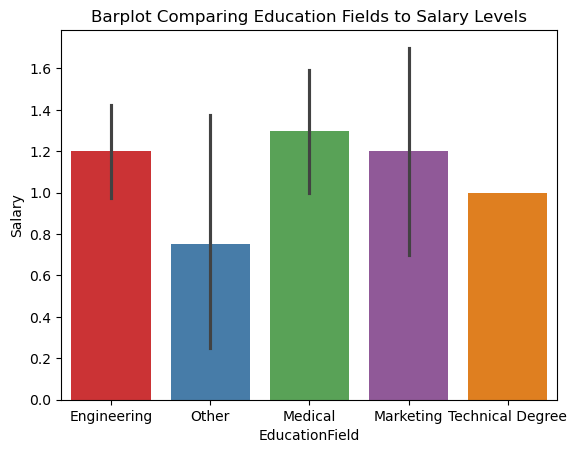

In [24]:
sns.barplot(x='EducationField', y='Salary', data=attr, palette='Set1')
plt.title('Barplot Comparing Education Fields to Salary Levels')
plt.show

It can be inferred from this chart that an employee's salary depended heavily on their field of study, with those holding medicine-related degrees averaging the highest salary level.

<function matplotlib.pyplot.show(close=None, block=None)>

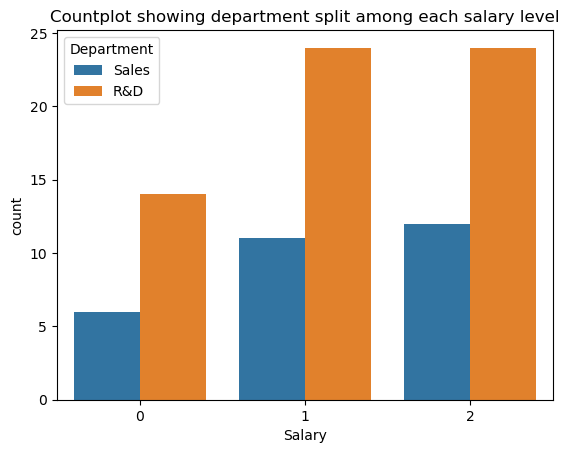

In [25]:
sns.countplot(x='Salary', hue='Department', data=attr)
plt.title("Countplot showing department split among each salary level")
plt.show

This count plot shows that while there were generally far more employees in R&D than in sales, the proportion of employees in sales was higher in higher salary levels.

# Step 3
Now, we carry out all remaining preprocessing to prepare the dataset for modelling

In [29]:
attr['Business Travel'] = attr['Business Travel'].map({
    'No': 0,
    'Rare': 1,
    'Frequent': 2
})

In [27]:
from sklearn.preprocessing import LabelEncoder

en = LabelEncoder()
feats = ['Home-Office', 'Gender', 'Department', 'EducationField', 'Attrition']

for feat in feats:
    attr[feat] = en.fit_transform(attr[feat])

In [28]:
attr.head(11)

,Gender,Satisfaction,Business Travel,Department,EducationField,Salary,Home-Office,Attrition
0,0,2,1,1,0,1,1,1
1,1,0,2,1,0,0,1,1
2,1,1,1,0,3,1,0,0
3,0,0,2,0,0,1,0,1
4,1,1,1,0,2,1,0,0
5,1,2,2,0,0,0,0,0
6,0,2,1,0,2,2,0,0
7,1,2,1,0,0,2,1,0
8,1,2,2,0,0,2,1,0
9,1,1,1,0,2,2,1,0


The dataset is now fully encoded

# Step 4
The next step is to create our models

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [31]:
x = attr['Attrition']
y = attr.drop(columns='Attrition')

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [32]:
scores = []

def test(name, model):
    scores.append({
        'Model': name,
        'Max Depth': model.max_depth if hasattr(model, 'max_depth') else None,
        'Accuracy': accuracy_score(y_test, model.predict(x_test)),
        'Recall': recall_score(y_test, model.predict(x_test)),
        'Precision': precision_score(y_test, model.predict(x_test)),
        'F1 Score': f1_score(y_test, model.predict(x_test))
    })

In [33]:
trees = {}

for depth in range(1, 10):
    trees[depth] = DecisionTreeClassifier(max_depth=depth, random_state=42)
    trees[depth].fit(x_train, y_train)
    test(f"Decision Tree {index(depth) + 1}", trees[depth])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.